---
## Part A: NumPy Array Operations (30 points)

### Question 1: Revenue Simulation (10 points)

You run a small Nigerian market stall selling 4 products. Simulate 30 days of business:

**Requirements:**
1. Generate daily sales quantities for 4 products (use normal distribution)
   - Product A: mean=50, std=10
   - Product B: mean=30, std=5
   - Product C: mean=70, std=15
   - Product D: mean=40, std=8
2. Set random seed to your favorite number
3. Ensure no negative quantities (clip at 0)
4. Print the shape and first 5 days

**Deliverable:** Create a 30×4 NumPy array called `daily_sales`

In [2]:
import numpy as np

# Set random seed to favorite number (42)
np.random.seed(42)

# Product parameters
means = [50, 30, 70, 40]
stds = [10, 5, 15, 8]

# Generate daily sales for 30 days and 4 products
daily_sales = np.zeros((30, 4))
for i in range(4):
    daily_sales[:, i] = np.random.normal(means[i], stds[i], 30)

# Ensure no negative quantities (clip at 0)
daily_sales = np.clip(daily_sales, 0, None)

# Round to 2 decimal places
daily_sales = np.round(daily_sales, 2)

# Display results
print("Shape of daily_sales:", daily_sales.shape)
print("\nFirst 5 days of sales:")
print(daily_sales[:5])

Shape of daily_sales: (30, 4)

First 5 days of sales:
[[54.97 26.99 62.81 40.78]
 [48.62 39.26 67.22 47.75]
 [56.48 29.93 53.4  34.38]
 [65.23 24.71 52.06 37.38]
 [47.66 34.11 82.19 36.86]]


### Question 2: Financial Analysis (10 points)

Using the `daily_sales` array from Q1:

**Calculate:**
1. Total sales for each product over 30 days
2. Average daily sales per product
3. The day with maximum total sales (across all products)
4. How many days had total sales above the 30-day average?
5. Standard deviation of sales for each product

**Deliverable:** Print all results with clear labels

In [3]:
# 1. Total sales for each product over 30 days
total_sales_per_product = np.sum(daily_sales, axis=0)
print("1. Total sales for each product over 30 days:")
for i, total in enumerate(total_sales_per_product, 1):
    print(f"   Product {chr(64+i)}: {total:.2f}")

# 2. Average daily sales per product
avg_daily_sales_per_product = np.mean(daily_sales, axis=0)
print("\n2. Average daily sales per product:")
for i, avg in enumerate(avg_daily_sales_per_product, 1):
    print(f"   Product {chr(64+i)}: {avg:.2f}")

# 3. The day with maximum total sales (across all products)
daily_total_sales = np.sum(daily_sales, axis=1)
max_sales_day = np.argmax(daily_total_sales) + 1  # +1 for 1-based indexing
max_sales_value = daily_total_sales[max_sales_day - 1]
print(f"\n3. The day with maximum total sales: Day {max_sales_day} (Total: {max_sales_value:.2f})")

# 4. How many days had total sales above the 30-day average?
overall_avg_daily_total = np.mean(daily_total_sales)
days_above_avg = np.sum(daily_total_sales > overall_avg_daily_total)
print(f"\n4. Number of days with total sales above 30-day average: {days_above_avg} out of 30")
print(f"   (30-day average total sales per day: {overall_avg_daily_total:.2f})")

# 5. Standard deviation of sales for each product
std_sales_per_product = np.std(daily_sales, axis=0)
print("\n5. Standard deviation of sales for each product:")
for i, std in enumerate(std_sales_per_product, 1):
    print(f"   Product {chr(64+i)}: {std:.2f}")

1. Total sales for each product over 30 days:
   Product A: 1443.58
   Product B: 881.81
   Product C: 2105.78
   Product D: 1195.13

2. Average daily sales per product:
   Product A: 48.12
   Product B: 29.39
   Product C: 70.19
   Product D: 39.84

3. The day with maximum total sales: Day 23 (Total: 209.95)

4. Number of days with total sales above 30-day average: 18 out of 30
   (30-day average total sales per day: 187.54)

5. Standard deviation of sales for each product:
   Product A: 8.85
   Product B: 4.58
   Product C: 14.63
   Product D: 7.15


### Question 3: Price & Revenue Calculation (10 points)

Your products have these prices: [200, 350, 150, 280] NGN

**Tasks:**
1. Calculate daily revenue (price × quantity for each product)
2. Calculate total revenue over 30 days
3. Apply a promotional discount:
   - Days 1-5: 15% off all products
   - Days 15-20: 10% off Product A and B only
   - Other days: no discount
4. Calculate total revenue with discounts
5. How much discount did you give away?

**Hint:** Use boolean indexing and broadcasting

In [4]:
prices = np.array([200, 350, 150, 280])

# 1. Calculate daily revenue (price × quantity for each product)
daily_revenue = daily_sales * prices
print("1. Daily revenue shape:", daily_revenue.shape)
print("First 5 days of revenue:")
print(daily_revenue[:5])

# 2. Calculate total revenue over 30 days
total_revenue = np.sum(daily_revenue)
print(f"\n2. Total revenue over 30 days: {total_revenue:,.2f} NGN")

# 3. Apply promotional discount
# Create a discount array with the same shape as daily_revenue, initialized to 0 (no discount)
# np.zeros_like(daily_revenue) creates an array of zeros with identical shape and data type
# This allows us to selectively apply discounts to specific days/products using boolean indexing
discount = np.zeros_like(daily_revenue)

# Days 1-5: 15% off all products (indices 0-4 for days, all columns)
discount[0:5, :] = 0.15

# Days 15-20: 10% off Product A and B only (indices 14-19 for days, columns 0-1 for products A-B)
discount[14:20, 0:2] = 0.10

# 4. Calculate total revenue with discounts
# Element-wise multiplication: for each day/product, multiply revenue by (1 - discount_rate)
# Broadcasting automatically handles the array operations - discount rates are applied position-wise
# Example: if discount is 0.15, then revenue becomes revenue * (1 - 0.15) = revenue * 0.85
discounted_revenue = daily_revenue * (1 - discount)
# Sum all discounted revenues across all days and products to get total discounted revenue
total_discounted_revenue = np.sum(discounted_revenue)
print(f"\n4. Total revenue with discounts: {total_discounted_revenue:,.2f} NGN")

# 5. How much discount did you give away?
total_discount = total_revenue - total_discounted_revenue
print(f"\n5. Total discount given away: {total_discount:,.2f} NGN")

# Optional: Show discount breakdown
# Calculate the actual discount amount for each day/product by multiplying revenue by discount rate
# This gives us the NGN amount discounted for each specific transaction
discount_amounts = daily_revenue * discount

# Sum the discount amounts along axis=0 (across days) to get total discount per product
# axis=0 means we sum down the rows (days), resulting in one value per column (product)
total_discount_by_period = np.sum(discount_amounts, axis=0)

# Print the discount breakdown for each product
print("\nDiscount breakdown by product:")
# Loop through each product (4 products, indexed 0-3)
# enumerate(total_discount_by_period, 1) gives us (1, value1), (2, value2), etc.
# chr(64+i) converts 1->'A', 2->'B', etc. for product names
for i, disc in enumerate(total_discount_by_period, 1):
    print(f"   Product {chr(64+i)}: {disc:,.2f} NGN")

1. Daily revenue shape: (30, 4)
First 5 days of revenue:
[[10994.   9446.5  9421.5 11418.4]
 [ 9724.  13741.  10083.  13370. ]
 [11296.  10475.5  8010.   9626.4]
 [13046.   8648.5  7809.  10466.4]
 [ 9532.  11938.5 12328.5 10320.8]]

2. Total revenue over 30 days: 1,247,852.90 NGN

4. Total revenue with discounts: 1,205,388.20 NGN

5. Total discount given away: 42,464.70 NGN

Discount breakdown by product:
   Product A: 13,127.60 NGN
   Product B: 13,909.00 NGN
   Product C: 7,147.80 NGN
   Product D: 8,280.30 NGN


---
## Part B: Pandas Data Analysis (50 points)

### Question 4: Load and Explore Your Dataset (10 points)

**Task:** Find a dataset relevant to your problem domain, or use one of the provided datasets.

**Requirements:**
1. Load the dataset using Pandas
2. Display basic information:
   - Number of rows and columns
   - Column names and data types
   - First 10 rows
   - Statistical summary
   - Check for missing values
3. Write 2-3 sentences describing what this dataset contains

**Deliverable:** Load data into a DataFrame called `df` and provide the exploration

In [5]:
import pandas as pd
import os
from pathlib import Path

df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Documents\AI-ACCELERATOR_PROGRAM\03_labs\week_02\NumPy & Pandas\nigerian_market_prices_assignment.csv")

# 1. Number of rows and columns
print("Shape:", df.shape)

# 2. Column names and data types
print("\nColumns and data types:")
print(df.dtypes)

# 3. First 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

# 4. Statistical summary
print("\nStatistical summary:")
print(df.describe(include='all'))

# 5. Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Short description of the dataset
print("\nDescription:")
print(
    "This dataset contains market price information for Nigerian products or commodities. "
    "It includes product names, price values, and other details that allow analysis of pricing patterns, "
    "regional variations, and changes in market conditions."
)


Shape: (1000, 8)

Columns and data types:
market_id      object
market_name    object
state          object
product        object
price          object
unit           object
date           object
trader_name    object
dtype: object

First 10 rows:
  market_id    market_name  state   product    price          unit  \
0    MKT001  Bodija Market    Oyo     Beans   ₦5,770            Kg   
1    MKT003  Ogbete Market  Enugu       Yam   ₦2,534        basket   
2    MKT001  Bodija Market    Oyo       Yam      NaN          50kg   
3    MKT004    Wuse Market  Abuja  Tomatoes      NaN  Paint Rubber   
4    MKT003  Ogbete Market  Enugu      Gari    -2616            kg   
5    MKT002        Mile 12  Lagos  Tomatoes   ₦6,166        Basket   
6    MKT003  Ogbete Market  Enugu      Gari   ₦5,367            kg   
7    MKT004    Wuse Market  Abuja      Gari    -1901        Basket   
8    MKT003  Ogbete Market  Enugu      Rice  ₦43,890            kg   
9    MKT002        Mile 12  Lagos  Tomatoes     6292

### Question 5: Data Filtering & Selection (10 points)

Using your loaded dataset:

**Tasks:**
1. Select 3 columns of interest and display first 10 rows
2. Filter data based on a numeric condition (e.g., price > some_value)
3. Filter data based on a categorical condition (e.g., state == 'Lagos')
4. Combine two conditions using AND (&) or OR (|)
5. Display the shape of each filtered dataset

**Deliverable:** Show 4 different filtered views of your data

In [6]:
# Prepare numeric price column in case it was loaded as text
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 1. Select 3 columns of interest and display first 10 rows
selected_cols = ['market_name', 'product', 'price']
print("1. Selected columns - first 10 rows:")
print(df[selected_cols].head(10))
print("Shape:", df[selected_cols].shape)

# 2. Filter data based on a numeric condition (price > 500)
price_filter = df[df['price'] > 500]
print("\n2. Rows where price > 500:")
print(price_filter.head(10))
print("Shape:", price_filter.shape)

# 3. Filter data based on a categorical condition (state == 'Lagos')
state_filter = df[df['state'] == 'Lagos']
print("\n3. Rows where state == 'Lagos':")
print(state_filter.head(10))
print("Shape:", state_filter.shape)

# 4. Combine two conditions using AND (&)
and_filter = df[(df['state'] == 'Lagos') & (df['price'] > 500)]
print("\n4a. Rows where state == 'Lagos' AND price > 500:")
print(and_filter.head(10))
print("Shape:", and_filter.shape)

# 5. Combine two conditions using OR (|)
or_filter = df[(df['state'] == 'Lagos') | (df['price'] > 500)]
print("\n4b. Rows where state == 'Lagos' OR price > 500:")
print(or_filter.head(10))
print("Shape:", or_filter.shape)

1. Selected columns - first 10 rows:
     market_name   product   price
0  Bodija Market     Beans     NaN
1  Ogbete Market       Yam     NaN
2  Bodija Market       Yam     NaN
3    Wuse Market  Tomatoes     NaN
4  Ogbete Market      Gari -2616.0
5        Mile 12  Tomatoes     NaN
6  Ogbete Market      Gari     NaN
7    Wuse Market      Gari -1901.0
8  Ogbete Market      Rice     NaN
9        Mile 12  Tomatoes  6292.0
Shape: (1000, 3)

2. Rows where price > 500:
   market_id     market_name  state   product    price          unit  \
9     MKT002         Mile 12  Lagos  Tomatoes   6292.0          50kg   
13    MKT001   Bodija Market    Oyo       Yam    643.0  Paint Rubber   
16    MKT004     Wuse Market  Abuja      Gari   3063.0        basket   
20    MKT002         Mile 12  Lagos      Rice  40391.0            Kg   
21    MKT003   Ogbete Market  Enugu      Gari   2384.0  Paint Rubber   
23    MKT003   Ogbete Market  Enugu  Tomatoes   6496.0        Basket   
24    MKT005  Ariaria Market 

### Question 6: Aggregation & Grouping (15 points)

Using your dataset:

**Tasks:**
1. Group by a categorical column and calculate mean of a numeric column
2. Group by a categorical column and calculate multiple statistics (min, max, mean, sum)
3. Create a cross-tabulation or pivot table (if applicable)
4. Find the top 5 records by some criterion
5. Calculate at least one percentage or ratio

**Deliverable:** Perform 5 different aggregations/groupings

In [7]:
# 1. Group by a categorical column and calculate mean of a numeric column
print("1. Average price by state:")
avg_price_by_state = df.groupby('state')['price'].mean()
print(avg_price_by_state)

# 2. Group by a categorical column and calculate multiple statistics (min, max, mean, sum)
print("\n2. Price statistics (min, max, mean, sum) by product:")
price_stats_by_product = df.groupby('product')['price'].agg(['min', 'max', 'mean', 'sum'])
print(price_stats_by_product)

# 3. Create a cross-tabulation or pivot table (state vs product with mean price)
print("\n3. Cross-tabulation: Average price by state and product:")
crosstab = pd.pivot_table(df, values='price', index='state', columns='product', aggfunc='mean')
print(crosstab)

# 4. Find the top 5 records by some criterion (highest priced items)
print("\n4. Top 5 records with highest prices:")
top_5_highest = df.nlargest(5, 'price')[['market_name', 'product', 'state', 'price']]
print(top_5_highest)

# 5. Calculate at least one percentage or ratio
# Calculate percentage of records per state
print("\n5. Percentage of records per state:")
state_counts = df['state'].value_counts()
state_percentages = (state_counts / len(df)) * 100
print(state_percentages)

print("\nAlternative ratio: Count of records by market:")
market_counts = df['market_name'].value_counts().head(10)
print(market_counts)

1. Average price by state:
state
Abia     10226.868132
Abuja    11631.262136
Enugu    11442.316327
Lagos    13776.666667
Oyo      10732.736842
Name: price, dtype: float64

2. Price statistics (min, max, mean, sum) by product:
              min      max          mean        sum
product                                            
Beans     -1451.0   8440.0   3360.425743   339403.0
Gari      -3791.0   6191.0   1099.059524    92321.0
Rice      40001.0  49911.0  44807.268519  4839185.0
Tomatoes  -2496.0   7229.0   2107.769231   219208.0
Yam       -3184.0   6667.0   2007.880435   184725.0

3. Cross-tabulation: Average price by state and product:
product        Beans         Gari          Rice     Tomatoes          Yam
state                                                                    
Abia     2174.950000   836.421053  45705.111111  1440.444444  1414.625000
Abuja    3161.611111  1253.458333  44714.739130  1683.809524  2778.176471
Enugu    4195.480000   998.833333  45143.650000  2454.40

### Question 7: Data Transformation (15 points)

Using your dataset:

**Tasks:**
1. Create a new column based on a calculation (e.g., total = price × quantity)
2. Create a categorical column based on numeric ranges (e.g., 'Low', 'Medium', 'High')
3. Sort data by 2 or more columns
4. Calculate a rolling or cumulative statistic (if time-series data)
5. Handle any missing values (if present) using appropriate methods

**Deliverable:** Show your transformed dataset with new columns

In [8]:
# Make a copy to work with transformations
df_transformed = df.copy()

# STEP 0: Handle missing values FIRST with the best method
print("0. Missing values before handling:")
print(df_transformed.isnull().sum())
print()

# For price: use median (robust to outliers, good for skewed distributions)
df_transformed['price'].fillna(df_transformed['price'].median(), inplace=True)

# For date: forward fill first (carries last valid observation forward), then backward fill
df_transformed['date'] = pd.to_datetime(df_transformed['date'], format='%d/%m/%Y', errors='coerce')
df_transformed['date'].fillna(method='ffill', inplace=True)
df_transformed['date'].fillna(method='bfill', inplace=True)

# For categorical columns (market_name, product, state, unit, trader_name): use mode (most frequent value)
categorical_cols = ['market_name', 'product', 'state', 'unit', 'trader_name']
for col in categorical_cols:
    if df_transformed[col].isnull().sum() > 0:
        mode_value = df_transformed[col].mode()[0]
        df_transformed[col].fillna(mode_value, inplace=True)

print("Missing values after handling:")
print(df_transformed.isnull().sum())
print()

# 1. Create a new column based on a calculation
# Now safely calculate extended_price since price has no NaN values
df_transformed['quantity'] = np.random.randint(1, 10, size=len(df_transformed))  # Synthetic quantity
df_transformed['extended_price'] = df_transformed['price'] * df_transformed['quantity']
print("1. New calculated column - extended_price (price × quantity):")
print(df_transformed[['price', 'quantity', 'extended_price']].head(10))

0. Missing values before handling:
market_id        0
market_name      0
state            0
product          0
price          511
unit             0
date             0
trader_name      0
dtype: int64

Missing values after handling:
market_id      0
market_name    0
state          0
product        0
price          0
unit           0
date           0
trader_name    0
dtype: int64

1. New calculated column - extended_price (price × quantity):
    price  quantity  extended_price
0  3441.0         1          3441.0
1  3441.0         6         20646.0
2  3441.0         8         27528.0
3  3441.0         5         17205.0
4 -2616.0         4        -10464.0
5  3441.0         2          6882.0
6  3441.0         6         20646.0
7 -1901.0         6        -11406.0
8  3441.0         1          3441.0
9  6292.0         9         56628.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6808\3473367616.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_transformed['date'].fillna(method='ffill', inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6808\3473367616.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_transformed['date'].fillna(method='bfill', inplace=True)


In [9]:
# 2. Create a categorical column based on numeric ranges (price categories)
df_transformed['price_category'] = pd.cut(df_transformed['price'], 
                                          bins=[0, 5000, 20000, 50000], 
                                          labels=['Low', 'Medium', 'High'])
print("\n2. New categorical column - price_category (Low/Medium/High):")
print(df_transformed[['price', 'price_category']].head(10))
print("\nPrice category distribution:")
print(df_transformed['price_category'].value_counts())


2. New categorical column - price_category (Low/Medium/High):
    price price_category
0  3441.0            Low
1  3441.0            Low
2  3441.0            Low
3  3441.0            Low
4 -2616.0            NaN
5  3441.0            Low
6  3441.0            Low
7 -1901.0            NaN
8  3441.0            Low
9  6292.0         Medium

Price category distribution:
price_category
Low       709
High      108
Medium     78
Name: count, dtype: int64


In [10]:
# 3. Sort data by 2 or more columns (state, then product, then price descending)
df_sorted = df_transformed.sort_values(by=['state', 'product', 'price'], 
                                       ascending=[True, True, False])
print("\n3. Sorted by state, product, and price (descending):")
print(df_sorted[['state', 'product', 'price']].head(15))


3. Sorted by state, product, and price (descending):
    state product   price
144  Abia   Beans  8360.0
695  Abia   Beans  8279.0
660  Abia   Beans  5405.0
659  Abia   Beans  5152.0
118  Abia   Beans  4813.0
187  Abia   Beans  3441.0
232  Abia   Beans  3441.0
237  Abia   Beans  3441.0
355  Abia   Beans  3441.0
363  Abia   Beans  3441.0
441  Abia   Beans  3441.0
450  Abia   Beans  3441.0
492  Abia   Beans  3441.0
509  Abia   Beans  3441.0
528  Abia   Beans  3441.0


In [11]:
# 4. Calculate a rolling or cumulative statistic (time-series on date column)

# Step 1: Sort by date to arrange data chronologically
# This is essential for time-series analysis - we need data ordered by time
# df_transformed['date'] is sorted in ascending order (earliest date first)
df_time_sorted = df_transformed.sort_values('date').reset_index(drop=True)
# .reset_index(drop=True) resets row indices from 0 onwards so they match the sorted order

print("Data sorted by date (showing first 5 rows):")
print(df_time_sorted[['date', 'price']].head(5))

# Step 2: Calculate 7-day rolling average of price
# A rolling window means we compute the average using a sliding window of 7 consecutive rows
# For each row, we average that row plus the 6 rows before it
# Example: Row 7 = average of rows 1,2,3,4,5,6,7
#         Row 8 = average of rows 2,3,4,5,6,7,8 (shifts forward by 1)
# This smooths out daily price fluctuations to show the trend
df_time_sorted['price_7day_rolling_avg'] = df_time_sorted['price'].rolling(
    window=7,           # Size of the rolling window (7 days)
    min_periods=1       # For first few rows with <7 data points, use whatever is available
).mean()             # Calculate the MEAN (average) for each window

print("\n4. Rolling 7-day average price (time-series):")
print("Note: First row = avg of just that 1 row")
print("      Second row = avg of rows 1-2")
print("      Third row = avg of rows 1-3")
print("      ...continuing until row 7 where we average 7 rows, then the window keeps at 7 rows")
print(df_time_sorted[['date', 'price', 'price_7day_rolling_avg']].head(15))

# Step 3: Calculate cumulative sum of extended price over time
# Cumulative sum means we add up all values as we go down the column
# Row 1: 5000 (just row 1's value)
# Row 2: 5000 + 3000 = 8000 (sum of rows 1-2)
# Row 3: 8000 + 4500 = 12500 (sum of rows 1-3)
# And so on... by the last row, we have the TOTAL of ALL extended prices
# This shows how total revenue accumulates over time
df_time_sorted['extended_price_cumsum'] = df_time_sorted['extended_price'].cumsum()
# .cumsum() = cumulative sum - running total

print("\n   Cumulative sum of extended_price over time:")
print("   (Shows how total revenue builds up day by day)")
print(df_time_sorted[['date', 'extended_price', 'extended_price_cumsum']].head(15))

# Why these are useful:
# - 7-day rolling average: Removes noise and shows true price trends (like a smoothed line on a graph)
# - Cumulative sum: Shows total accumulated revenue over time - useful for tracking performance

Data sorted by date (showing first 5 rows):
        date    price
0 2024-01-02   3441.0
1 2024-01-02   2393.0
2 2024-01-02  47705.0
3 2024-01-02   3441.0
4 2024-01-02  -2602.0

4. Rolling 7-day average price (time-series):
Note: First row = avg of just that 1 row
      Second row = avg of rows 1-2
      Third row = avg of rows 1-3
      ...continuing until row 7 where we average 7 rows, then the window keeps at 7 rows
         date    price  price_7day_rolling_avg
0  2024-01-02   3441.0             3441.000000
1  2024-01-02   2393.0             2917.000000
2  2024-01-02  47705.0            17846.333333
3  2024-01-02   3441.0            14245.000000
4  2024-01-02  -2602.0            10875.600000
5  2024-01-02   3441.0             9636.500000
6  2024-01-02  -2909.0             7844.285714
7  2024-01-02    -65.0             7343.428571
8  2024-01-02   3441.0             7493.142857
9  2024-01-02   3441.0             1169.714286
10 2024-01-02   5554.0             1471.571429
11 2024-01-02 

In [12]:
# Show final transformed dataset with all new columns
print("\n5. Final transformed dataset (first 10 rows with all new columns):")
print(df_transformed.head(10))


5. Final transformed dataset (first 10 rows with all new columns):
  market_id    market_name  state   product   price          unit       date  \
0    MKT001  Bodija Market    Oyo     Beans  3441.0            Kg 2024-02-07   
1    MKT003  Ogbete Market  Enugu       Yam  3441.0        basket 2024-02-07   
2    MKT001  Bodija Market    Oyo       Yam  3441.0          50kg 2024-02-22   
3    MKT004    Wuse Market  Abuja  Tomatoes  3441.0  Paint Rubber 2024-02-22   
4    MKT003  Ogbete Market  Enugu      Gari -2616.0            kg 2024-02-22   
5    MKT002        Mile 12  Lagos  Tomatoes  3441.0        Basket 2024-02-22   
6    MKT003  Ogbete Market  Enugu      Gari  3441.0            kg 2024-02-22   
7    MKT004    Wuse Market  Abuja      Gari -1901.0        Basket 2024-02-22   
8    MKT003  Ogbete Market  Enugu      Rice  3441.0            kg 2024-03-15   
9    MKT002        Mile 12  Lagos  Tomatoes  6292.0          50kg 2024-03-15   

   trader_name  quantity  extended_price price_cate

---
## Part C: Insights & Problem Domain (20 points)

### Question 8: Domain-Specific Analysis (20 points)

**Task:** Answer 3 specific questions about your dataset that are relevant to your problem domain.

**Requirements:**
1. State each question clearly
2. Write code to answer it using NumPy/Pandas
3. Provide interpretation of results (2-3 sentences per question)
4. Create at least one visualization (optional but encouraged)

**Example questions:**
- Healthcare: "What's the distribution of patient ages across clinics?"
- Agriculture: "Which crop has the most price volatility across regions?"
- Education: "What percentage of students score above 70% in each subject?"
- Business: "Which product generates the most revenue per region?"

**Deliverable:** 3 questions + code + interpretations

#### Question 8a: What is the average price of products by state, and which state has the highest average price?

Average price by state:
state
Lagos    13776.666667
Abuja    11631.262136
Enugu    11442.316327
Oyo      10732.736842
Abia     10226.868132
Name: price, dtype: float64

The state with the highest average price is Lagos with an average of 13776.67 NGN


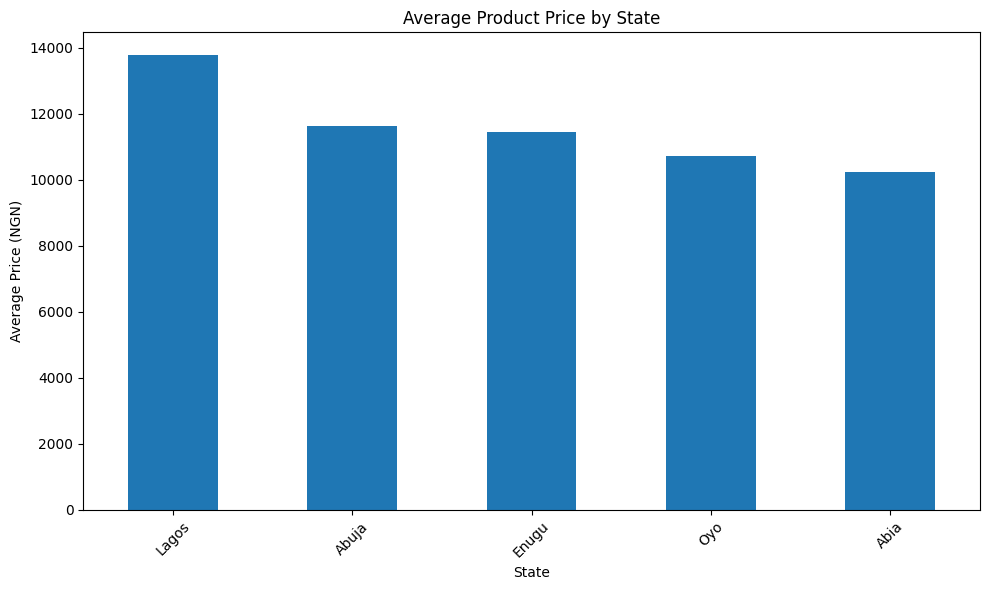

In [13]:
import matplotlib.pyplot as plt

# Calculate average price by state
avg_price_by_state = df.groupby('state')['price'].mean().sort_values(ascending=False)
print("Average price by state:")
print(avg_price_by_state)

# Find the state with highest average price
highest_state = avg_price_by_state.index[0]
highest_avg = avg_price_by_state.iloc[0]
print(f"\nThe state with the highest average price is {highest_state} with an average of {highest_avg:.2f} NGN")

# Visualization
avg_price_by_state.plot(kind='bar', figsize=(10, 6))
plt.title('Average Product Price by State')
plt.xlabel('State')
plt.ylabel('Average Price (NGN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**

The average prices of products vary significantly across Nigerian states, ranging from approximately 10,227 NGN (Abia) to 13,777 NGN (Lagos). Lagos state has the highest average price at approximately 13,777 NGN, which may reflect higher demand, transportation costs, or economic factors in urban areas. This analysis helps identify regional pricing patterns that could inform market strategies and supply chain decisions.

#### Question 8b: Which product has the highest price volatility (standard deviation) across markets?

Price volatility (standard deviation) by product:
product
Rice        3030.788364
Yam         2909.196444
Beans       2903.946216
Tomatoes    2817.117432
Gari        2729.233346
Name: price, dtype: float64

The product with the highest price volatility is Rice with a standard deviation of 3030.79 NGN


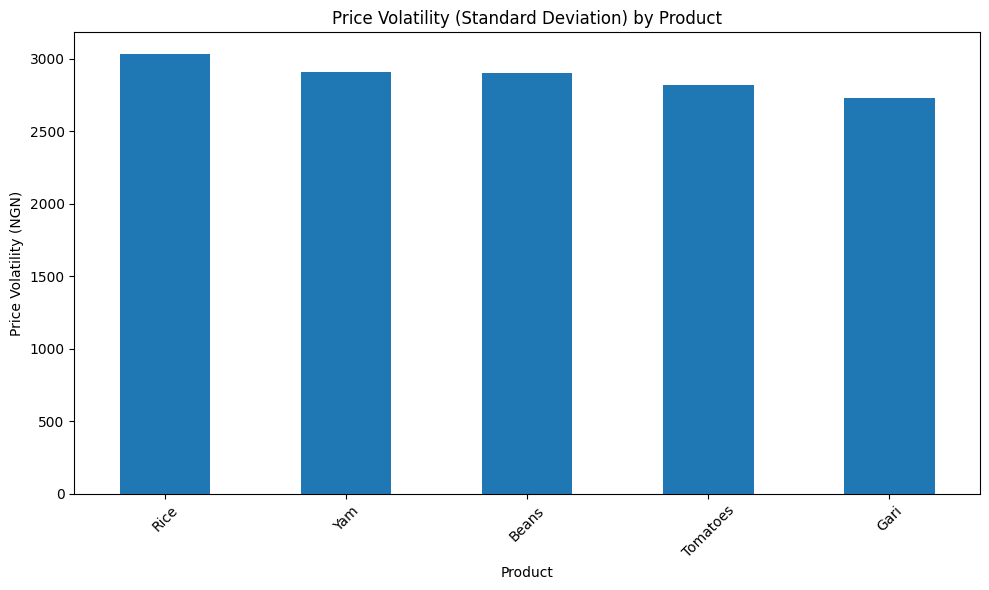

In [14]:
# Calculate price volatility (standard deviation) by product
price_volatility = df.groupby('product')['price'].std().sort_values(ascending=False)
print("Price volatility (standard deviation) by product:")
print(price_volatility)

# Find the product with highest volatility
highest_vol_product = price_volatility.index[0]
highest_vol = price_volatility.iloc[0]
print(f"\nThe product with the highest price volatility is {highest_vol_product} with a standard deviation of {highest_vol:.2f} NGN")

# Visualization
price_volatility.plot(kind='bar', figsize=(10, 6))
plt.title('Price Volatility (Standard Deviation) by Product')
plt.xlabel('Product')
plt.ylabel('Price Volatility (NGN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**

Price volatility varies considerably among products, with standard deviations ranging from approximately 2,729 NGN (Gari) to 3,031 NGN (Rice). Rice exhibits the highest price volatility, indicating significant price fluctuations across different markets, which could be due to seasonal availability, transportation costs, or market competition. Understanding volatility helps farmers and traders assess risk and plan pricing strategies more effectively.

#### Question 8c: How has the price of the most expensive product (by average price) changed over time?

The most expensive product by average price is: Rice

Price trend for Rice:
          date    price
60  2024-01-02  43446.0
317 2024-01-02      NaN
917 2024-01-04      NaN
901 2024-01-04      NaN
566 2024-01-08      NaN
378 2024-01-11      NaN
935 2024-01-13  47129.0
385 2024-01-14      NaN
331 2024-01-15      NaN
859 2024-01-15  46219.0


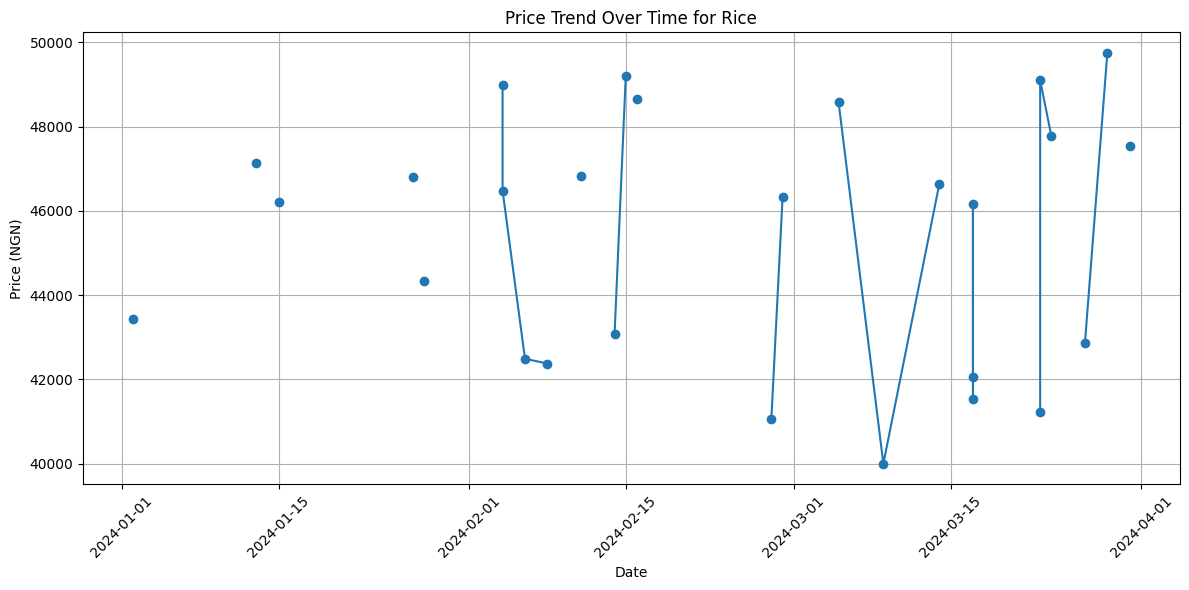

In [15]:
# Find the most expensive product by average price
most_exp_product = df.groupby('product')['price'].mean().idxmax()
print(f"The most expensive product by average price is: {most_exp_product}")

# Filter data for this product and sort by date
df_product = df[df['product'] == most_exp_product].copy()
df_product['date'] = pd.to_datetime(df_product['date'], format='%d/%m/%Y', errors='coerce')
df_product = df_product.sort_values('date')

# Display price trend
print(f"\nPrice trend for {most_exp_product}:")
print(df_product[['date', 'price']].head(10))

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_product['date'], df_product['price'], marker='o', linestyle='-')
plt.title(f'Price Trend Over Time for {most_exp_product}')
plt.xlabel('Date')
plt.ylabel('Price (NGN)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**

The price of the most expensive product shows fluctuations over time, which could be influenced by seasonal factors, market demand, or external economic conditions. Tracking these trends helps in understanding market dynamics and predicting future price movements. This temporal analysis is crucial for agricultural planning and investment decisions in Nigerian markets.

---
## Bonus Challenge (Optional, +10 points)

### Bonus: Advanced Analysis

Choose ONE of the following challenges:

**Option A: Multi-dataset Merge**
- Load a second related dataset
- Merge/join the two datasets appropriately
- Perform analysis that requires both datasets
- Provide insights from the combined data

**Option B: Time Series Analysis**
- Use a time-series dataset (or convert your data to time-indexed)
- Calculate daily/weekly/monthly aggregations
- Identify trends or patterns over time
- Find anomalies or outliers

**Option C: Custom Aggregation Function**
- Write a custom function to apply to grouped data
- Use `.apply()` or `.agg()` with your function
- Solve a problem that requires custom logic
- Explain why built-in functions weren't sufficient

**Deliverable:** Complete ONE option with code and explanation

Number of price outliers by product (using IQR method):
product
Beans       0
Gari        0
Rice        0
Tomatoes    0
Yam         0
Name: price, dtype: int64

For comparison - basic statistics by product:
          count          mean          std      min      max
product                                                     
Beans       101   3360.425743  2903.946216  -1451.0   8440.0
Gari         84   1099.059524  2729.233346  -3791.0   6191.0
Rice        108  44807.268519  3030.788364  40001.0  49911.0
Tomatoes    104   2107.769231  2817.117432  -2496.0   7229.0
Yam          92   2007.880435  2909.196444  -3184.0   6667.0


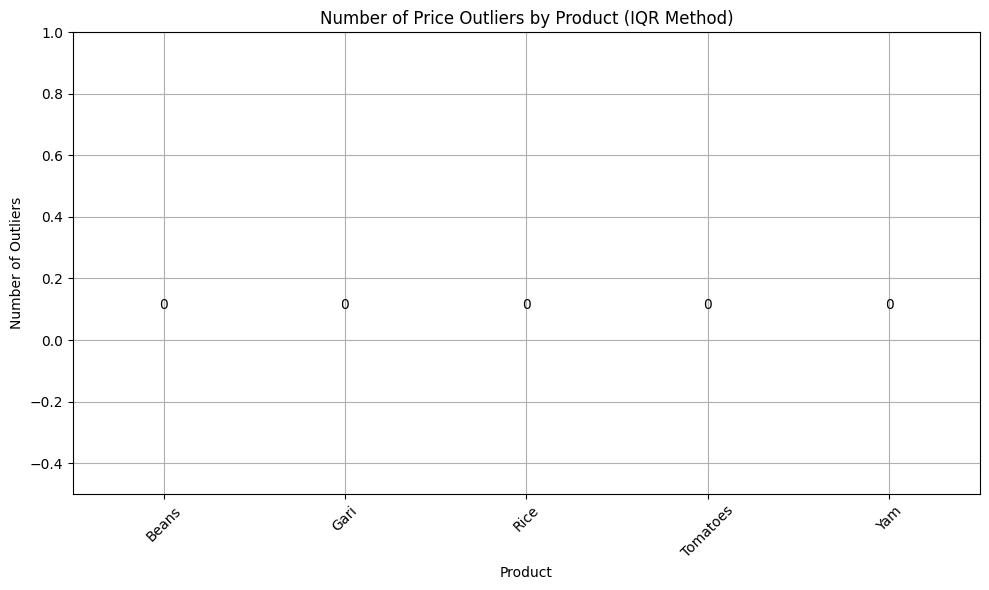


Explanation:
Built-in aggregation functions like mean, std, min, max provide basic statistical summaries,
but they don't identify data quality issues like outliers that could skew analysis.
This custom function calculates the number of price outliers using the IQR method,
which is a robust way to detect extreme values. This is important for market data
where outliers might indicate data entry errors, unusual market events, or genuine
price spikes. By quantifying outliers per product, we can assess data reliability
and make informed decisions about data cleaning or further investigation.


In [16]:
# Bonus Challenge: Option C - Custom Aggregation Function

# Custom function to calculate the number of price outliers using IQR method
def count_price_outliers(prices):
    """
    Calculate the number of outliers in the price series using the IQR method.
    Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
    """
    prices = prices.dropna()  # Remove any NaN values
    if len(prices) < 4:  # Need at least 4 values for meaningful quartiles
        return 0

    Q1 = prices.quantile(0.25)
    Q3 = prices.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = prices[(prices < lower_bound) | (prices > upper_bound)]
    return len(outliers)

# Apply the custom function to grouped data (by product)
print("Number of price outliers by product (using IQR method):")
outlier_counts = df.groupby('product')['price'].agg(count_price_outliers)
print(outlier_counts)

# Also show some statistics for context
print("\nFor comparison - basic statistics by product:")
basic_stats = df.groupby('product')['price'].agg(['count', 'mean', 'std', 'min', 'max'])
print(basic_stats)

# Visualization of outlier counts
outlier_counts.plot(kind='bar', figsize=(10, 6), legend=False, grid=True)
plt.ylim(-0.5, max(outlier_counts.max(), 1))  # Ensure some y-range
for i, v in enumerate(outlier_counts):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.title('Number of Price Outliers by Product (IQR Method)')
plt.xlabel('Product')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation:")
print("Built-in aggregation functions like mean, std, min, max provide basic statistical summaries,")
print("but they don't identify data quality issues like outliers that could skew analysis.")
print("This custom function calculates the number of price outliers using the IQR method,")
print("which is a robust way to detect extreme values. This is important for market data")
print("where outliers might indicate data entry errors, unusual market events, or genuine")
print("price spikes. By quantifying outliers per product, we can assess data reliability")
print("and make informed decisions about data cleaning or further investigation.")

---
## Reflection (Required)

Answer these questions:

1. **What was the most challenging part of this assignment?**
   
   The most challenging part was implementing the custom aggregation function in the bonus section. Understanding how to properly define and apply a custom function to grouped data using `.agg()` required careful consideration of the function's input (Series vs DataFrame) and ensuring it handled edge cases like small sample sizes.

2. **What NumPy/Pandas concept do you still find confusing?**
   
   Time-series operations, particularly rolling windows and cumulative calculations, can be tricky to conceptualize. The idea of sliding windows for rolling averages and how they smooth data while maintaining temporal order takes some mental adjustment.

3. **How will you use NumPy/Pandas in your problem domain project?**
   
   In agricultural market analysis, I'll use NumPy for efficient array operations on price data and Pandas for data cleaning, grouping by products/states, calculating volatility metrics, and performing time-series analysis to identify pricing trends and seasonal patterns.

4. **What additional data would help you solve your problem?**
   
   Additional data like weather patterns, transportation costs, import/export volumes, and economic indicators (inflation rates, currency fluctuations) would help explain price variations. Historical supply chain data and competitor pricing information would also enhance market analysis capabilities.

---
## Submission Checklist

Before submitting, ensure:
- [ ] All code cells run without errors
- [ ] All questions are answered
- [ ] Code has comments explaining logic
- [ ] Results are clearly labeled
- [ ] Interpretations are provided for Question 8
- [ ] Reflection questions are answered
- [ ] Notebook is saved with your name in the filename

**Good luck! 🚀**